### Cài đặt các thư viện

In [316]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


### 1. Khai báo thư viện

In [317]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [318]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

### 2. Tải và đọc dữ liệu

In [319]:
X_train = pd.read_csv("D:\DS111\DO AN\Data Preparation\processed_data\X_train.csv")
y_train = pd.read_csv("D:\DS111\DO AN\Data Preparation\processed_data\y_train.csv")

job_onehot_cols = ['job_admin.', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
                'job_management', 'job_retired', 'job_self-employed', 'job_services',
                'job_student', 'job_technician', 'job_unemployed'
            ]
df_job_onehot = X_train[job_onehot_cols]
X_train = X_train.drop(columns=job_onehot_cols)
data = X_train.copy()
data["y"] = y_train
data.head()

,age_group_encode,job_encode,marital_encode,education_encode,default_encode,balance_log,balance_flag,housing_encode,loan_encode,contact_encode,day_encode,month_encode,duration_log,campaign_log,pdays_log,pdays_contacted,previous_log,poutcome_encode,y
0,4,4,1,2.0,0,0.507291,0,1,0,0,0.985243,0.965926,0.430097,-0.909638,-0.467735,0,-0.424985,3,0
1,3,9,2,1.0,0,-0.588304,0,1,0,0,0.985243,0.965926,-0.160655,-0.909638,-0.467735,0,-0.424985,3,0
2,2,2,1,1.0,0,-0.604089,0,1,1,0,0.985243,0.965926,-0.898547,-0.909638,-0.467735,0,-0.424985,3,0
3,3,1,1,1.0,0,0.203197,0,1,0,0,0.985243,0.965926,-0.693703,-0.909638,-0.467735,0,-0.424985,3,0
4,2,4,1,2.0,0,-0.471857,0,1,0,0,0.985243,0.965926,-0.249885,-0.909638,-0.467735,0,-0.424985,3,0


In [320]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45084 entries, 0 to 45083
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age_group_encode  45084 non-null  int64  
 1   job_encode        45084 non-null  int64  
 2   marital_encode    45084 non-null  int64  
 3   education_encode  45084 non-null  float64
 4   default_encode    45084 non-null  int64  
 5   balance_log       45084 non-null  float64
 6   balance_flag      45084 non-null  int64  
 7   housing_encode    45084 non-null  int64  
 8   loan_encode       45084 non-null  int64  
 9   contact_encode    45084 non-null  int64  
 10  day_encode        45084 non-null  float64
 11  month_encode      45084 non-null  float64
 12  duration_log      45084 non-null  float64
 13  campaign_log      45084 non-null  float64
 14  pdays_log         45084 non-null  float64
 15  pdays_contacted   45084 non-null  int64  
 16  previous_log      45084 non-null  float6

In [321]:
# Kiểm tra giá trị khuyết
data.isnull().sum()

age_group_encode    0
job_encode          0
marital_encode      0
education_encode    0
default_encode      0
balance_log         0
balance_flag        0
housing_encode      0
loan_encode         0
contact_encode      0
day_encode          0
month_encode        0
duration_log        0
campaign_log        0
pdays_log           0
pdays_contacted     0
previous_log        0
poutcome_encode     0
y                   0
dtype: int64

In [322]:
data.columns

Index(['age_group_encode', 'job_encode', 'marital_encode', 'education_encode',
       'default_encode', 'balance_log', 'balance_flag', 'housing_encode',
       'loan_encode', 'contact_encode', 'day_encode', 'month_encode',
       'duration_log', 'campaign_log', 'pdays_log', 'pdays_contacted',
       'previous_log', 'poutcome_encode', 'y'],
      dtype='object')

In [323]:
data.dtypes

age_group_encode      int64
job_encode            int64
marital_encode        int64
education_encode    float64
default_encode        int64
balance_log         float64
balance_flag          int64
housing_encode        int64
loan_encode           int64
contact_encode        int64
day_encode          float64
month_encode        float64
duration_log        float64
campaign_log        float64
pdays_log           float64
pdays_contacted       int64
previous_log        float64
poutcome_encode       int64
y                     int64
dtype: object

In [324]:
data.shape

(45084, 19)

### 3. Thực hiện thống kê mô tả

In [325]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
age_group_encode,45084.0,2.568450e+00,1.041939,0.000000,2.000000,2.000000,3.000000,5.000000
job_encode,45084.0,4.291656e+00,3.239510,0.000000,1.000000,4.000000,7.000000,10.000000
marital_encode,45084.0,1.167798e+00,0.608548,0.000000,1.000000,1.000000,2.000000,2.000000
education_encode,45084.0,1.149987e+00,0.658345,0.000000,1.000000,1.000000,2.000000,2.000000
default_encode,45084.0,1.805519e-02,0.133153,0.000000,0.000000,0.000000,0.000000,1.000000
balance_log,45084.0,6.475641e-15,1.000011,-42.838600,-0.563273,-0.349898,0.162582,11.702853
balance_flag,45084.0,8.353296e-02,0.276689,0.000000,0.000000,0.000000,0.000000,1.000000
housing_encode,45084.0,5.572265e-01,0.496720,0.000000,0.000000,1.000000,1.000000,1.000000
loan_encode,45084.0,1.606778e-01,0.367238,0.000000,0.000000,0.000000,0.000000,1.000000
contact_encode,45084.0,6.392512e-02,0.244622,0.000000,0.000000,0.000000,0.000000,1.000000


### 4. Kiểm tra các thuộc tính sau tiền xử lý

Vì sau tiền xử lý thì có thêm các thuộc tính mới nên chúng tôi tiến hành tạo phân phối numerical mới sau phần log_transform và scaling data để kiểm tra xem log-transform và Standard Scaler đã làm các phân phối trở nên cân bằng hơn hay chưa.

In [326]:
df = data.copy()

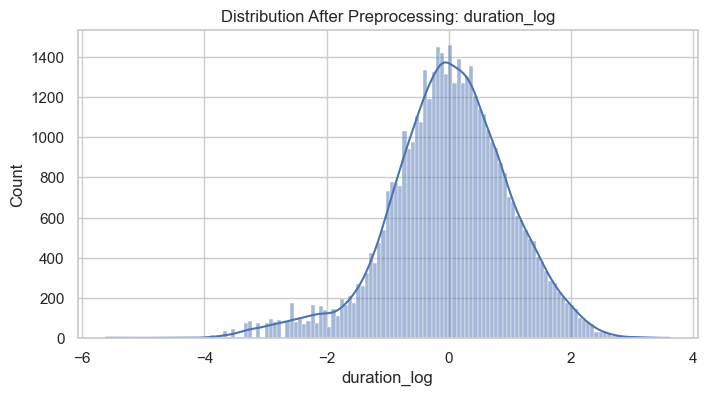

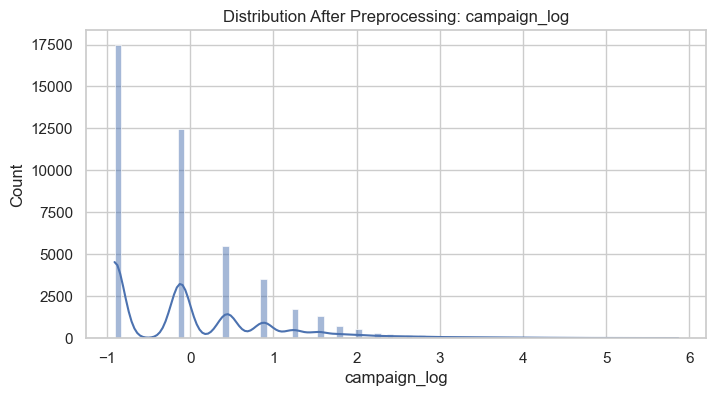

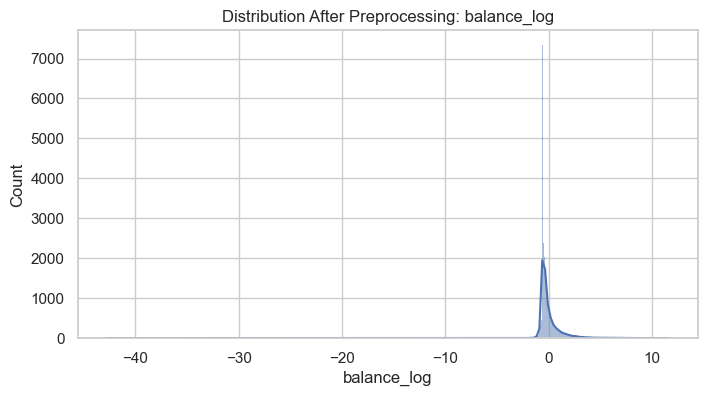

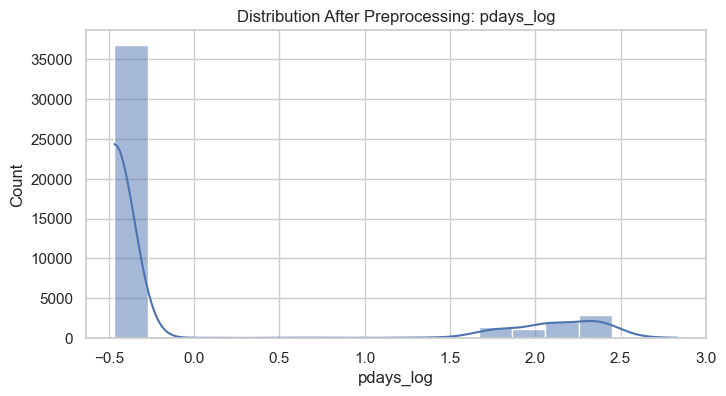

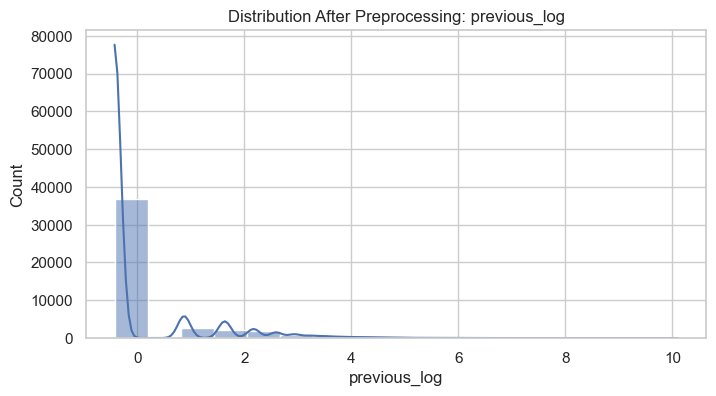

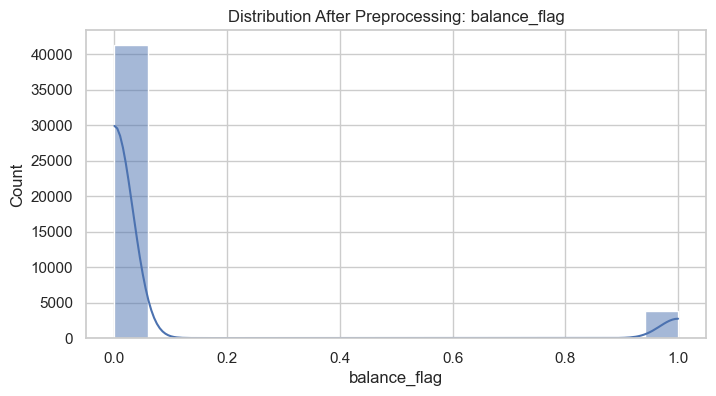

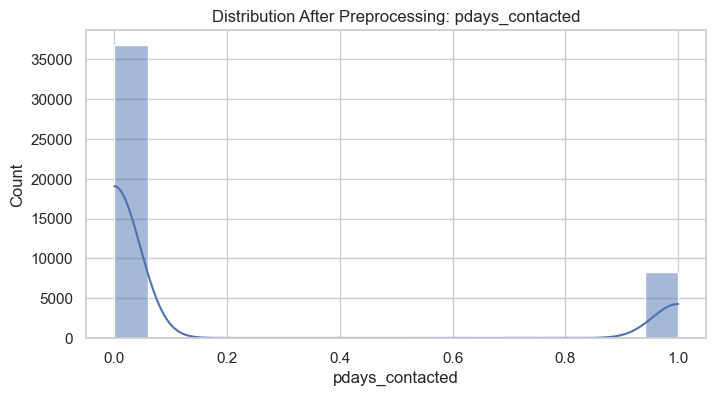

In [327]:
numerical_features = [
    'duration_log',
    'campaign_log',
    'balance_log',
    'pdays_log',
    'previous_log',
    'balance_flag',
    'pdays_contacted'
]

for col in numerical_features:
    plt.figure(figsize=(8,4))
    sns.histplot(data[col], kde=True)
    plt.title(f"Distribution After Preprocessing: {col}")
    plt.show()



#### 5. Kiểm tra mối quan hệ giữa các Feature với Target

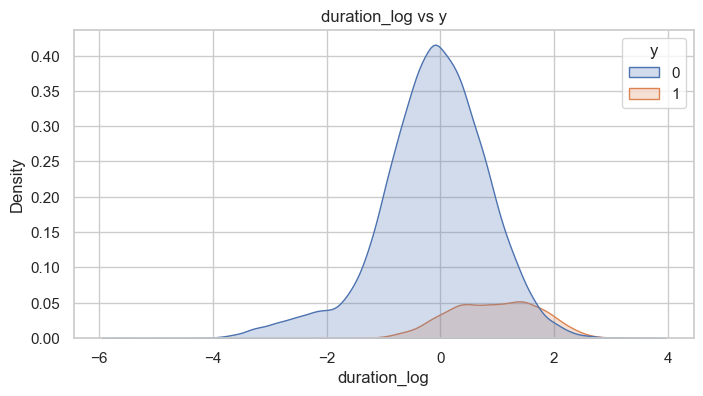

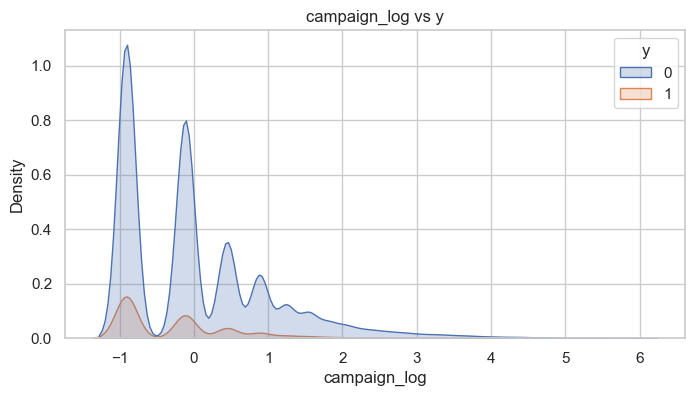

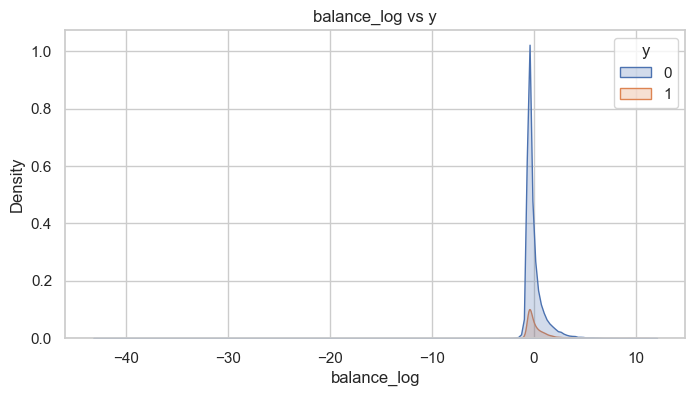

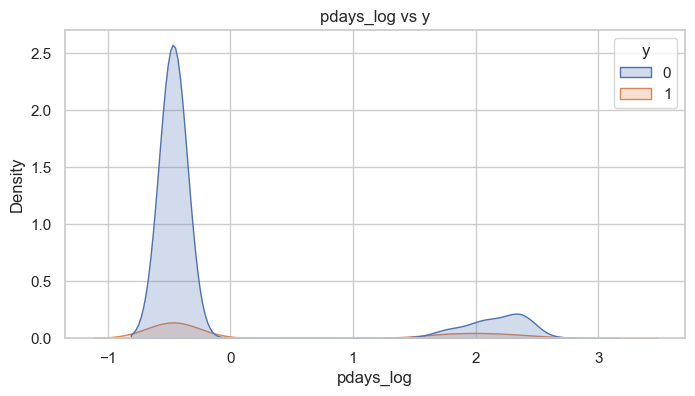

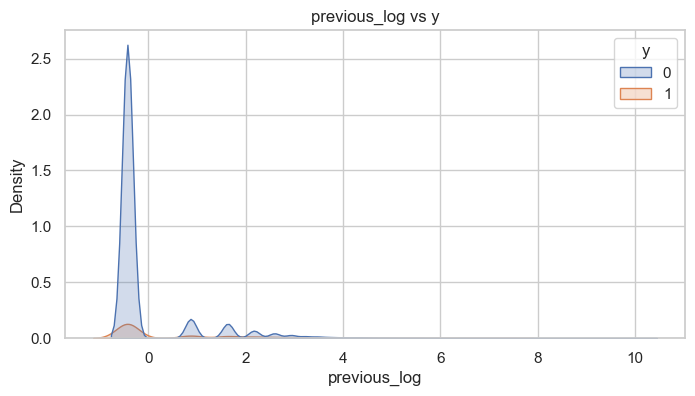

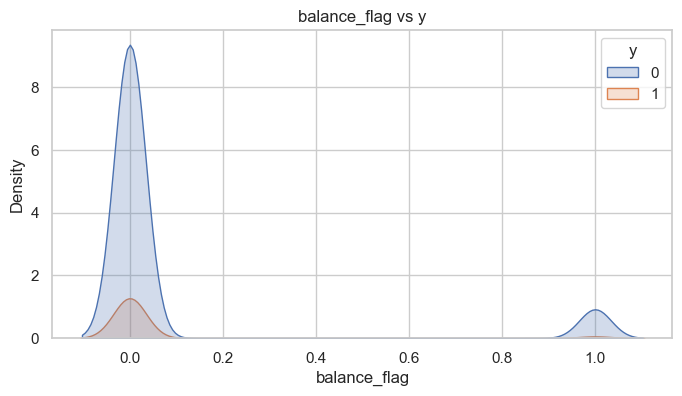

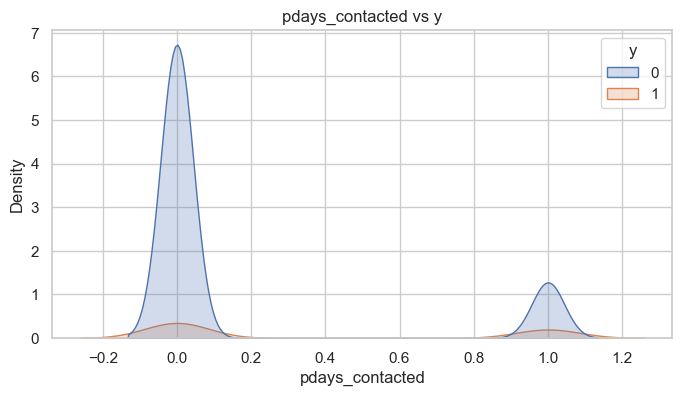

In [328]:
numerical_features = [
    'duration_log',
    'campaign_log',
    'balance_log',
    'pdays_log',
    'previous_log',
    'balance_flag',
    'pdays_contacted'
]

for col in numerical_features:
    plt.figure(figsize=(8,4))
    sns.kdeplot(data=data, x=col, hue='y', fill=True)
    plt.title(f"{col} vs y")
    plt.show()

### 6. Correlation Heatmap After Preprocessing

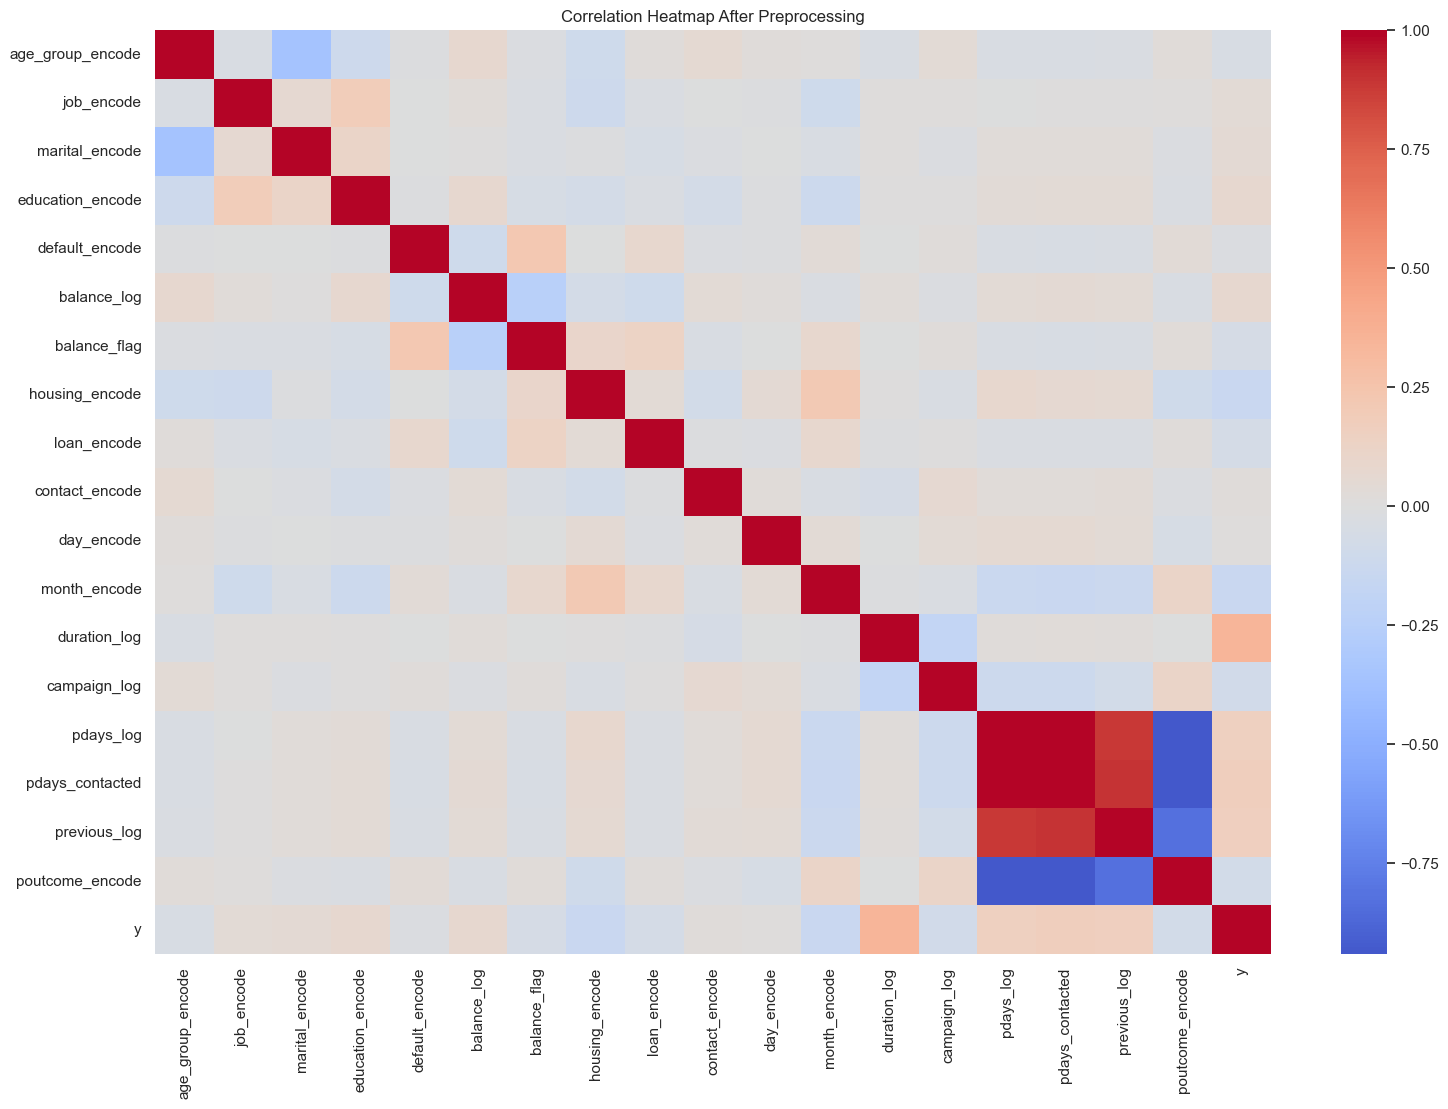

In [329]:
plt.figure(figsize=(18,12))
corr = data.corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap After Preprocessing")
plt.show()

Tương quan có sự thay đổi so với trước khi tiền xử lý, với các biến liên quan đến pdays thì có tương quan dương mạnh, trong khi biến poutcome và pdays thì 2 biến này tương quan âm lại rất thấp. Trong đó các biến job, marital, education cũng có sự ảnh hưởng tới kết quả khá cao khi chỉ số tương quan dương từ khoảng 0.25-0.5

### 7. Tạo Bins (phân nhóm) cho phân tích tương tác

In [330]:
data["duration_bin"] = pd.qcut(
    data["duration_log"], q=4,
    labels=["D_Low","D_Med","D_High","D_VHigh"],
    duplicates='drop'
)

data["balance_bin"] = pd.qcut(
    data["balance_log"], q=4,
    labels=["B_Low","B_Med","B_High","B_VHigh"],
    duplicates='drop'
)

data["campaign_bin"] = pd.cut(
    data["campaign_log"], bins=4,
    labels=["C_Low","C_Med","C_High","C_VHigh"],
    duplicates='drop'
)

data["pdays_bin"] = pd.cut(
    data["pdays_log"], bins=4,
    labels=["P_Low","P_Med","P_High","P_VHigh"],
    duplicates='drop'
)


### 8. Heatmap: Duration vs Age Group

C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\1509599983.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\1509599983.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\1509599983.py:25: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\1509599983.py:25: FutureWarning: The default v

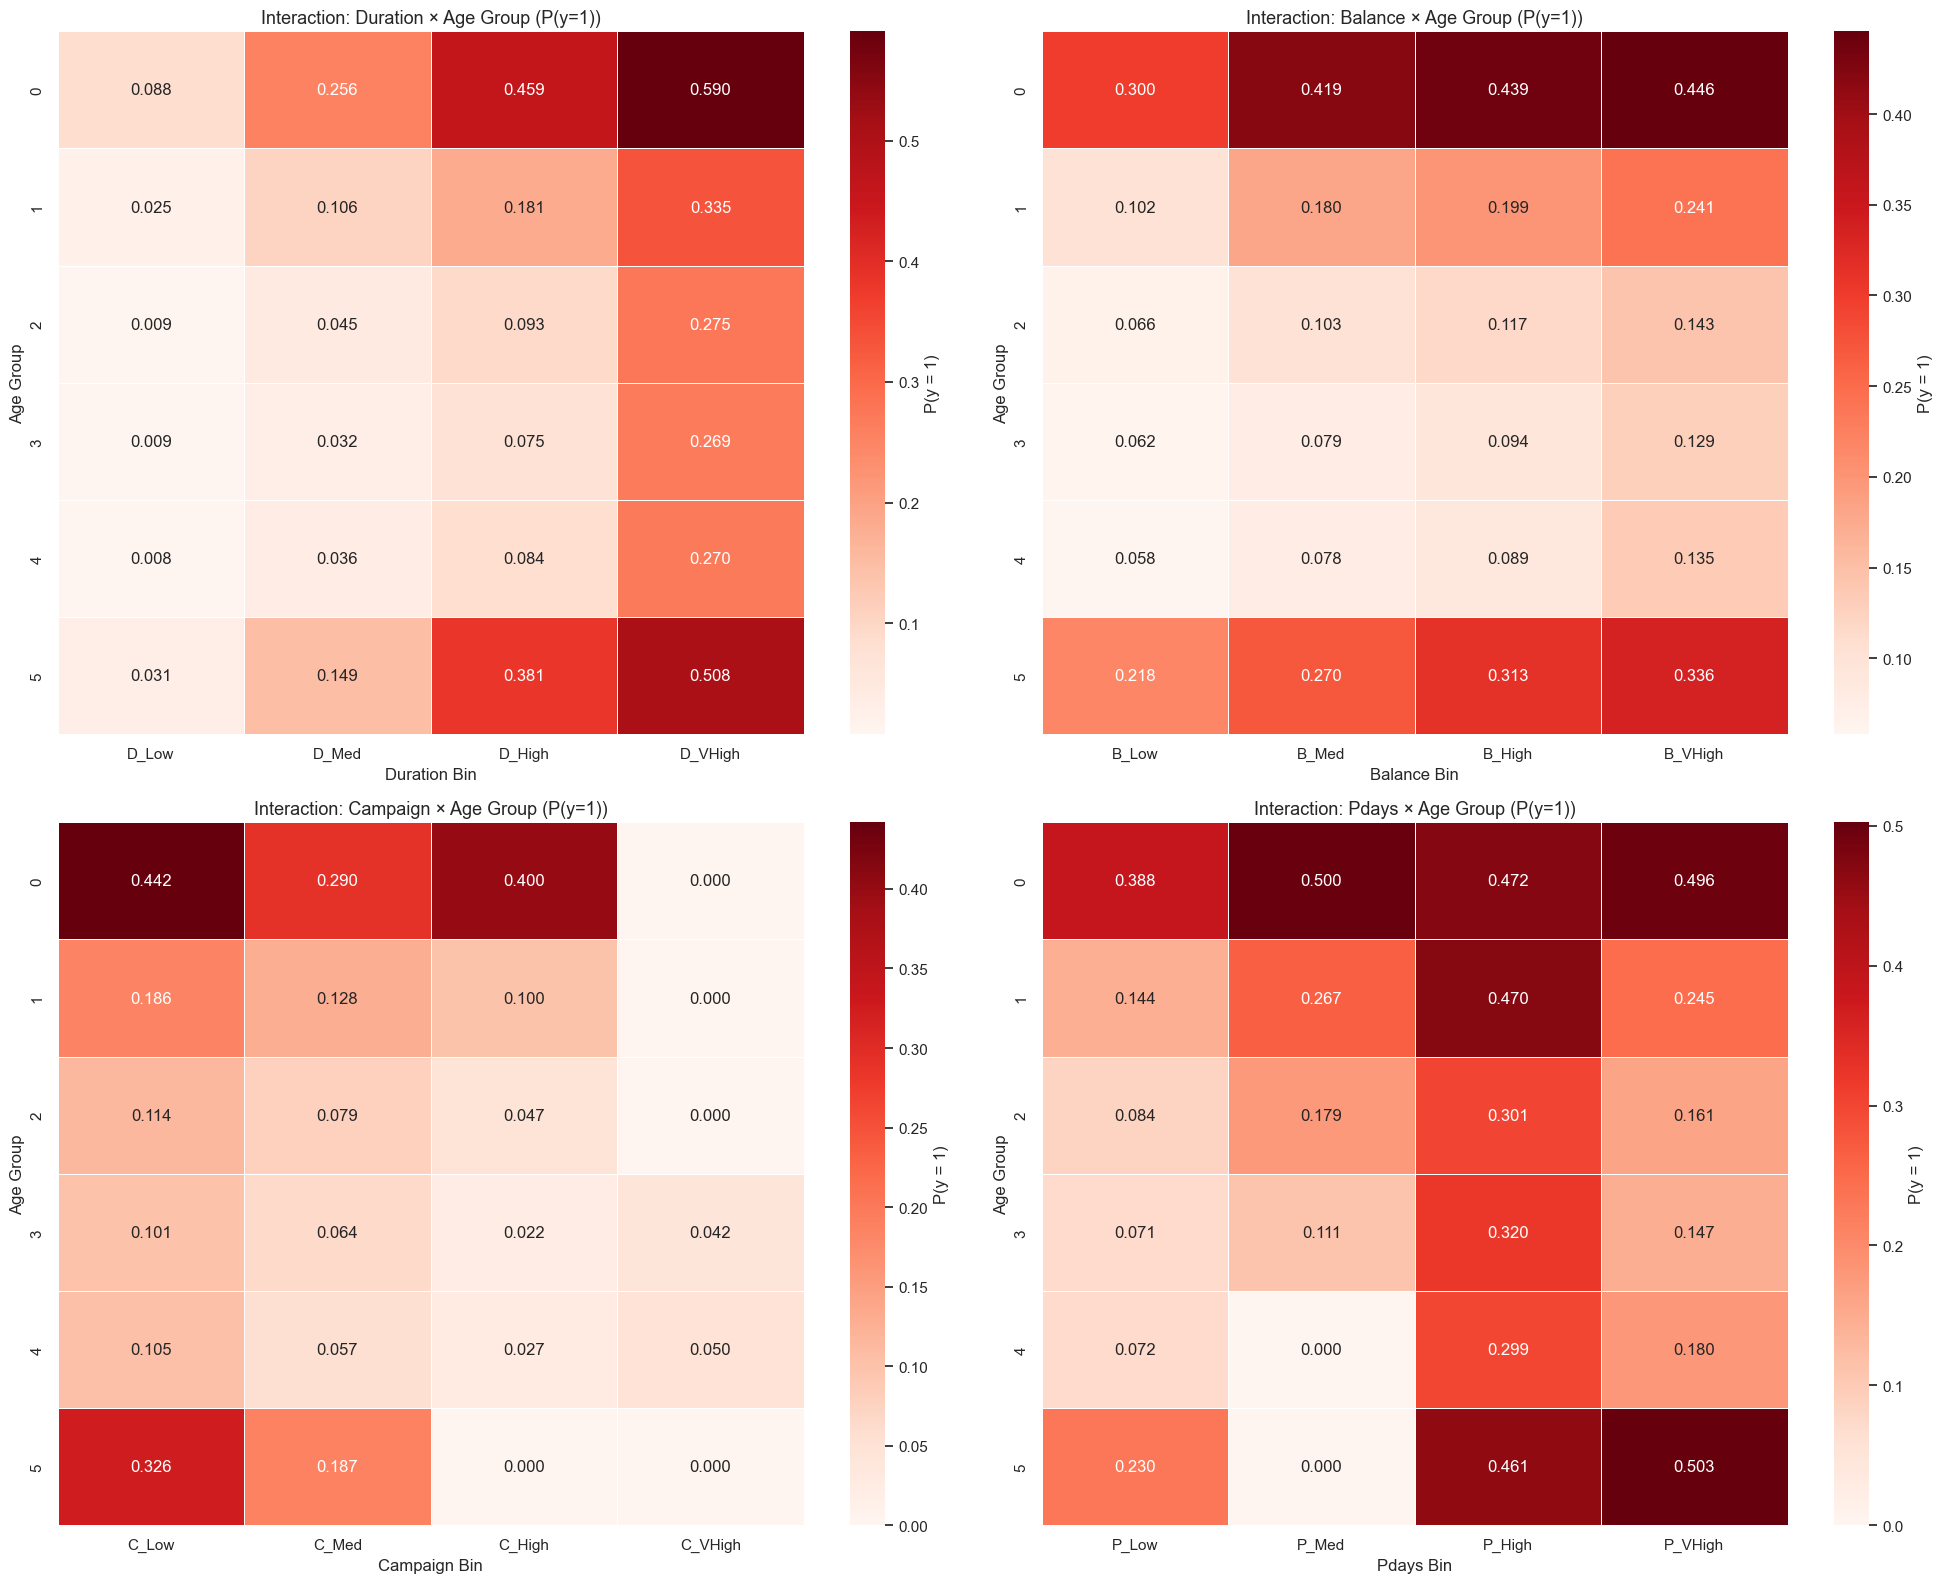

In [331]:
# Đảm bảo age_group có thứ tự đúng
data["age_group_encode"] = pd.Categorical(
    data["age_group_encode"],
    categories=sorted(data["age_group_encode"].unique()),
    ordered=True
)

# Tạo danh sách các cột bin cần phân tích
interaction_bins = [
    ("duration_bin", "Duration"),
    ("balance_bin", "Balance"),
    ("campaign_bin", "Campaign"),
    ("pdays_bin", "Pdays")
]


plt.figure(figsize=(20, 16))
plot_index = 1

for bin_col, title_prefix in interaction_bins:
    if bin_col not in data.columns:
        continue
    
    # Pivot table tính P(y=1) cho interaction
    pivot = data.pivot_table(
        index="age_group_encode",
        columns=bin_col,
        values="y",
        aggfunc="mean"
    ).fillna(0)
    
    # subplot
    plt.subplot(2, 2, plot_index)
    sns.heatmap(
        pivot,
        annot=True,
        cmap="Reds",
        fmt=".3f",
        linewidths=.5,
        cbar_kws={'label': 'P(y = 1)'}
    )
    
    plt.title(f"Interaction: {title_prefix} × Age Group (P(y=1))", fontsize=13)
    plt.xlabel(f"{title_prefix} Bin")
    plt.ylabel("Age Group")
    
    plot_index += 1

plt.tight_layout()
plt.show()


NOTE: CÁC NHÓM TUỐI: {0: U30, 1: U40, 2: U50, 3: U60, 4: U70, 5: U100}
1. Duration càng cao → tỉ lệ “yes” tăng mạnh trên mọi nhóm tuổi. Trong đó
- Nhóm tuổi U100 (nhóm lớn tuổi nhất) có tỉ lệ đăng ký cao khi thời gian trò chuyện/trao đổi dài.
- Các nhóm U30, U40, U50… có xu hướng tăng nhưng vẫn thấp hơn U100 & U70.
=> Từ đó có thể xác định Duration là yếu tố quyết định quan trọng nhất và người được tư vấn lâu hơn thường dễ đồng ý hơn.
- Khi thời lượng cuộc gọi tăng, tỷ lệ “YES – đăng ký gửi tiết kiệm” tăng mạnh ở tất cả các phân khúc.

2. Biểu đồ cho thấy người có Balance cao (Số dư tài khoản cao) thì xu hướng đăng ký (yes) lại không nhiều lắm
- Nhóm tuổi U100 và U30 lại có tỷ lệ đăng ký cao nếu balance cao. Trong khi 4 nhóm tuổi còn lại thì gần như không bị ảnh hưởng gì nếu số dư cao hay thấp.
=> Balance sẽ là thuộc tính có ảnh hưởng nhẹ đến khả năng đăng ký của khách hàng

3. Campaign (số lần liên hệ trong 1 chiến dịch): có thể thấy được nếu số campaign quá cao, có nghĩa là gọi quá nhiều thì tỷ lệ khách hàng đăng ký lại rất thấp (có thể họ thấy bị làm phiền, spam, ...), có thể thấy P(y=1) giảm mạnh, và đáng chú ý là C_VHigh toàn cột = 0 hoặc gần 0 -> người bị liên hệ tư vấn quá nhiều thường sẽ không đăng ký
- Tuy nhiên, ở nhóm U30 thì vẫn có khả năng đăng ký nếu gọi khá nhiều, các nhóm U40 - U70 thì hầu như không đăng ký nếu số lần liên hệ nhiều, và nhóm tuổi U100 vẫn có xu hướng đăng ký tuy nhiên vẫn sẽ không đăng ký nếu bị làm phiền nhiều.

4. Pdays (số lần liên hệ từ lần trước): có thể thấy khi pdays thấp thì tỷ lệ khách hàng đăng ký chiến dịch lại tăng, nhưng khi pdays cao thì tỷ lệ đăng ký lại vẫn cao => hiệu ứng phi tuyến mạnh (Quan hệ phi tuyến nghĩa là biến Pdays và xác suất khách hàng đồng ý không thay đổi theo một tỷ lệ cố định. Tỷ lệ đồng ý cao ở mức Pdays thấp, thấp ở mức trung bình, và lại tăng ở mức rất cao.)
- Nhóm tuổi U30 và U100 có tỷ lệ đăng ký cao kể cả pdays cao hay thấp
- Các nhóm tuổi còn lại có xu hướng đăng ký nếu pdays ở mức cao (P_High)

=> Duration là yếu tố mạnh nhất => Thời lượng cuộc gọi càng dài => tỷ lệ đồng ý càng cao
=> Campaign có ảnh hưởng tiêu cực => Gọi nhiều => khách hàng chán và giảm khả năng đồng ý
=> Balance ít ảnh hưởng => chỉ nhóm 0 và 5 phản ứng tốt khi balance cao.
=> Pdays quan hệ phi tuyến => cả last-contact gần và rất xa đều tăng tỷ lệ đồng ý.
=> Nhóm tuổi U30 và U100 phản ứng tích cực hơn ở tất cả các biến => Đây là phân khúc khách hàng dễ tiếp cận nhất.

C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\2599795931.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = data.pivot_table(


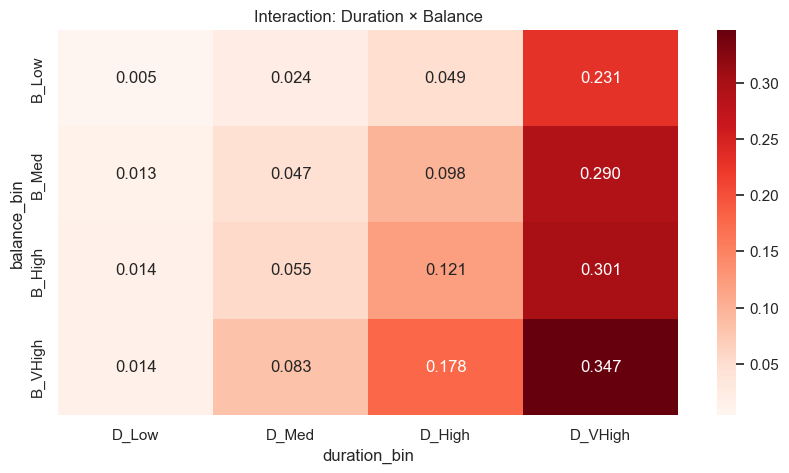

In [332]:
pivot = data.pivot_table(
    index="balance_bin",
    columns="duration_bin",
    values="y",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".3f")
plt.title("Interaction: Duration × Balance")
plt.show()


Duration (thời lượng cuộc gọi) dài → tỉ lệ “yes” tăng mạnh trên mọi mức Balance. Nhóm có Balance rất cao (B_VHigh) tăng tỉ lệ mạnh nhất.
=>  Khách có số dư tài khoản cao thường dễ chấp nhận đầu tư hơn → ảnh hưởng của duration với balance mạnh hơn.
=> Balance là biến độc lập mạnh, nhưng tăng mạnh khi kết hợp với Duration → đây là 1 sự tương tác quan trọng cần lưu ý.

C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\3122135833.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\3122135833.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\3122135833.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_sub.pivot_table(
C:\Users\Thy\AppData\Local\Temp\ipykernel_20500\3122135833.py:9: FutureWarning: The default

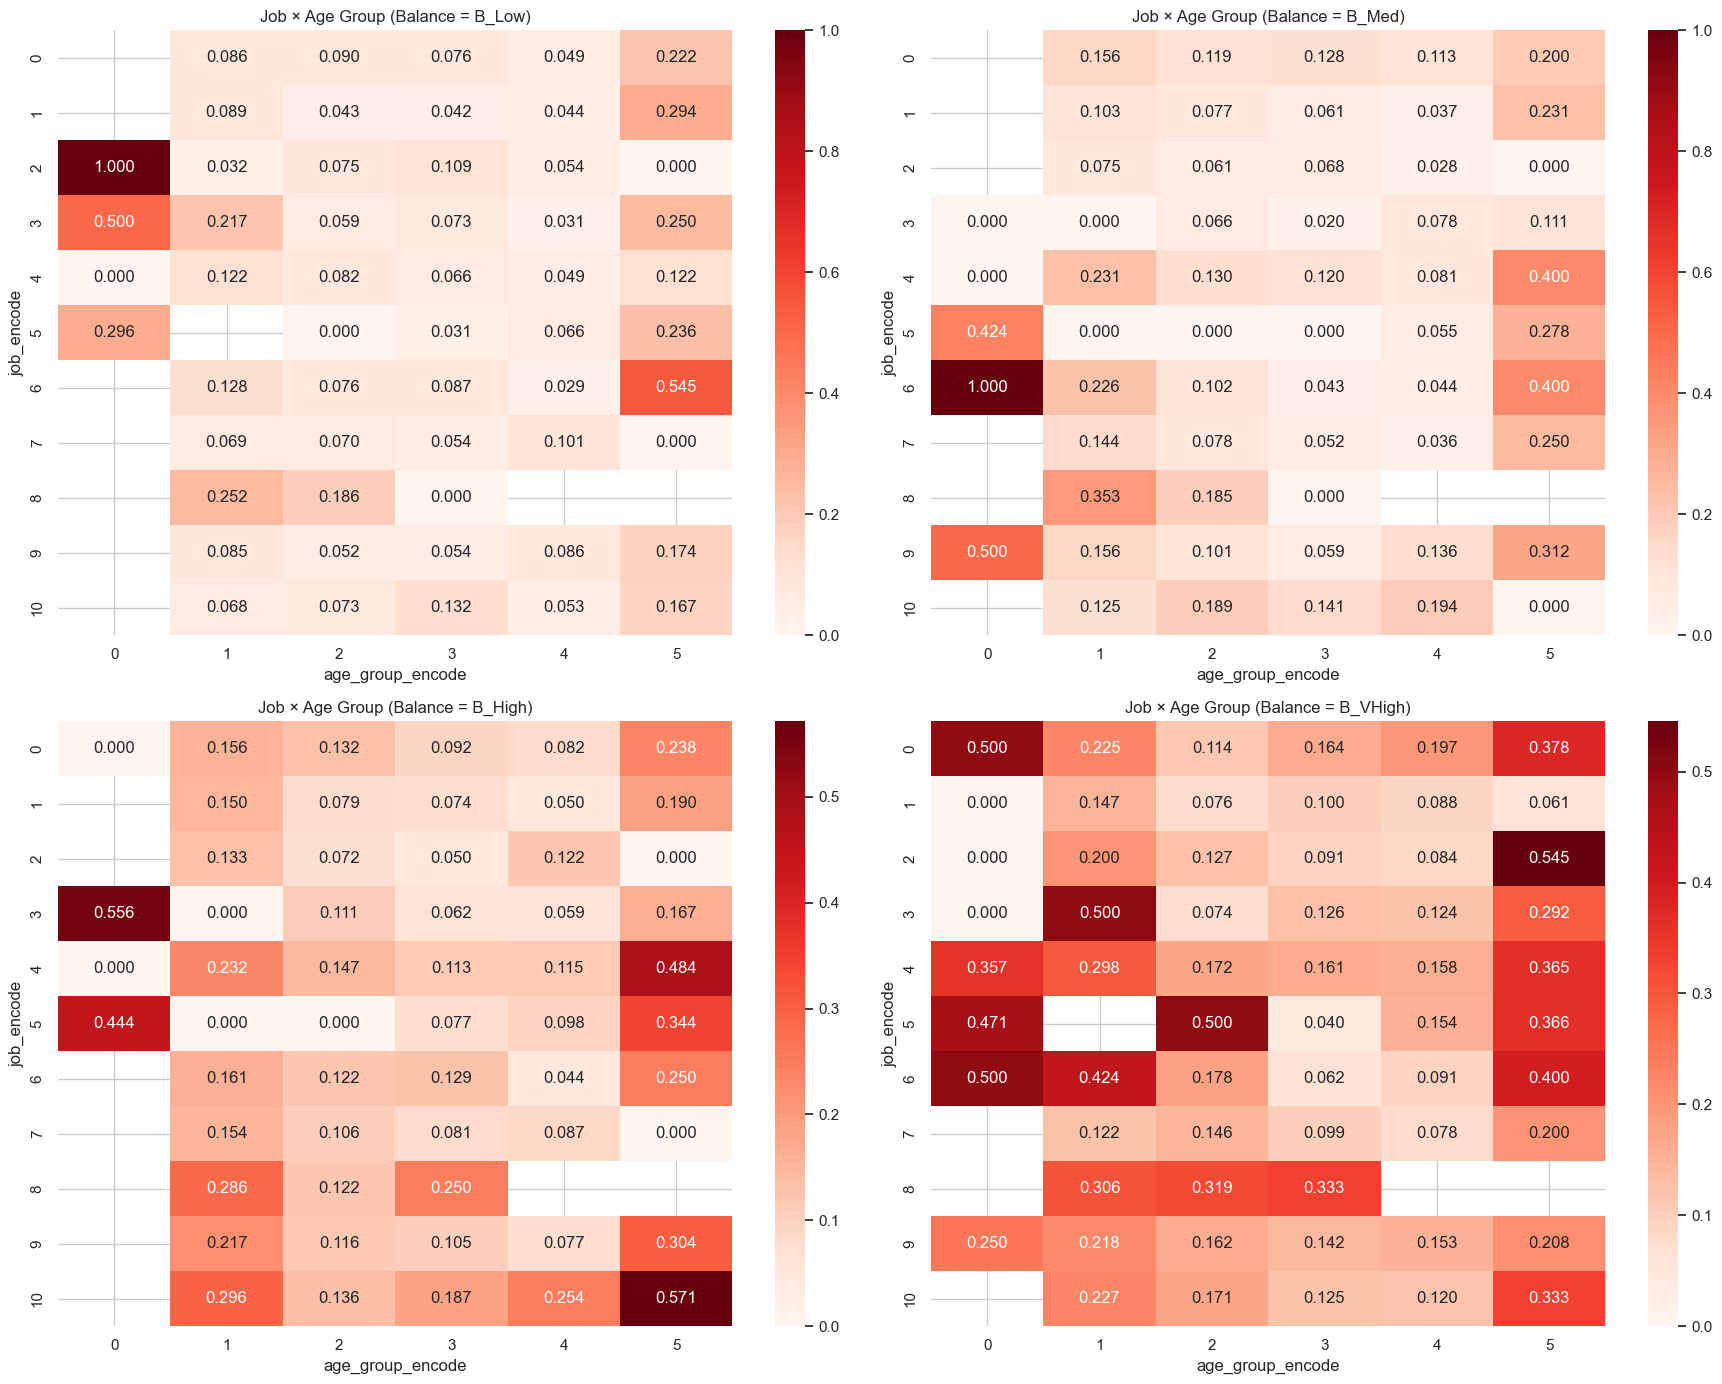

In [333]:
balance_levels = ["B_Low","B_Med","B_High","B_VHigh"]

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, bl in enumerate(balance_levels):
    df_sub = data[data["balance_bin"] == bl]
    
    pivot = df_sub.pivot_table(
        index="job_encode",
        columns="age_group_encode",
        values="y",
        aggfunc="mean"
    )
    
    sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".3f",
                ax=axes[i])
    axes[i].set_title(f"Job × Age Group (Balance = {bl})")

plt.tight_layout()
plt.show()


Nhận xét: 
- Nhóm U100, U70 thường có tỷ lệ cao hơn trên nhiều job.
- Certain jobs consistently cao hơn: entrepreneur (B_Low), retired, management, self-employed, unemployed. Riêng nhóm student cũng cao nhưng thay đổi theo balance.
- Balance càng cao → interaction càng mạnh
    - Khi balance thấp → heatmap “nhạt” hơn
    - Khi balance cao → màu đậm rõ rệt ở job retired, self-employed, management, unemployed
- Đối với các trường hợp:
    - Balance = B_Low: Chỉ một vài job có tỉ lệ cao bất thường (entrepreneur, housemaid nhưng đây có thể do sample ít → caution!)
    - Balance = B_Med: management, retired nổi bật
    - Balance = B_High: unemployed, management, services, student phản hồi mạnh hơn các nhóm khác
    - Balance = B_VHigh: retired, management, entrepreneur, self-employed → đậm rõ rệt → Người vừa có tiền, vừa ở nhóm ít áp lực tài chính / tự do thời gian → dễ đầu tư hơn.

### 9. Kiểm tra các features qua thuật toán RandomForest (thô) và Mutual Information (MI)

In [334]:
# RF
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

# Rút trích độ quan trọng
feature_importances = pd.Series(
    rf.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=False)
feature_importances

c:\Users\Thy\miniconda3\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


duration_log        0.316952
balance_log         0.138626
day_encode          0.090752
job_encode          0.058947
month_encode        0.055379
age_group_encode    0.054268
pdays_log           0.053624
poutcome_encode     0.050116
campaign_log        0.047204
housing_encode      0.028379
marital_encode      0.025704
education_encode    0.025488
previous_log        0.022100
loan_encode         0.011581
contact_encode      0.009271
pdays_contacted     0.005817
balance_flag        0.003934
default_encode      0.001860
dtype: float64

- Nhận xét:
1. duration_log (0.317)
Biến mạnh nhất tuyệt đối.
→ Yếu tố quan trọng nhất quyết định khách hàng đăng ký là thời lượng cuộc gọi.

2. balance_log (0.137)
Khách hàng có số dư cao → tỷ lệ đăng ký cao hơn.

3. day (0.0904) & month (0.0565)
Thời điểm gọi có ảnh hưởng → khá đặc biệt đối với tập Bank Marketing.

4. campaign_log & previous_log & pdays_log
Nhóm biến về lịch sử tiếp thị trước đó đều quan trọng.

5. contact_cellular, poutcome_success
Thông tin kênh liên hệ và trạng thái chiến dịch trước góp phần dự đoán tốt.

6. job, education, age_group
Nhóm nhân khẩu học, job (0.0588) và age_group(0.0527) khá cao và quan trọng hơn so với education chỉ có 0.0255

In [335]:
# Đo lường dữ liệu của các features với biến target
mi = mutual_info_classif(X_train, y_train)
features_mi = pd.Series(
    mi, 
    index=X_train.columns
).sort_values(ascending=False)
features_mi

c:\Users\Thy\miniconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


duration_log        0.072365
poutcome_encode     0.033136
pdays_log           0.029519
balance_log         0.021239
month_encode        0.017479
housing_encode      0.017187
previous_log        0.016769
pdays_contacted     0.013991
age_group_encode    0.012278
job_encode          0.010744
education_encode    0.004511
loan_encode         0.004480
campaign_log        0.004471
marital_encode      0.002953
day_encode          0.002738
balance_flag        0.002111
contact_encode      0.000029
default_encode      0.000000
dtype: float64

- Nhận xét: 
1. duration_log (MI = 0.072)
→ Cũng là đặc trưng mạnh nhất → đồng nhất với FI → càng chắc chắn.

2. poutcome (0.032)
→ Thành công từ chiến dịch trước rõ ràng có dự báo tốt.

3. pdays_log (0.028)
→ Yếu tố liên quan đến lần liên hệ trước → chứa nhiều thông tin hữu ích.

4. balance_log, month, housing, pdays_contacted, age-group, job
→ Các đặc trưng có MI tầm trung.

5. các biến còn lại
→ MI gần 0 → thông tin rất yếu.

In [336]:
# Đặt FI và MI vào chung 1 DataFrame
df_score = pd.DataFrame({
    "FI": feature_importances,
    "MI": mi
})

# Chuẩn hóa giá trị để so sánh công bằng
df_score["FI_norm"] = df_score["FI"] / df_score["FI"].max()
df_score["MI_norm"] = df_score["MI"] / df_score["MI"].max()

# Tính điểm tổng hợp (weighted)
df_score["score"] = 0.7 * df_score["FI_norm"] + 0.3 * df_score["MI_norm"]

# Sắp xếp theo sức mạnh feature
df_score_sorted = df_score.sort_values("score", ascending=False)

print("TOP FEATURE RANKING")
print(df_score_sorted)


TOP FEATURE RANKING
                        FI        MI   FI_norm   MI_norm     score
duration_log      0.316952  0.012278  1.000000  0.169671  0.750901
balance_log       0.138626  0.010744  0.437373  0.148472  0.350702
previous_log      0.022100  0.072365  0.069728  1.000000  0.348810
day_encode        0.090752  0.002953  0.286327  0.040802  0.212669
age_group_encode  0.054268  0.021239  0.171219  0.293491  0.207901
poutcome_encode   0.050116  0.017187  0.158118  0.237505  0.181934
job_encode        0.058947  0.004511  0.185982  0.062331  0.148887
contact_encode    0.009271  0.029519  0.029249  0.407923  0.142852
default_encode    0.001860  0.033136  0.005867  0.457893  0.141475
education_encode  0.025488  0.017479  0.080415  0.241533  0.128750
pdays_log         0.053624  0.002111  0.169187  0.029173  0.127183
campaign_log      0.047204  0.004480  0.148933  0.061903  0.122824
month_encode      0.055379  0.000000  0.174723  0.000000  0.122306
balance_flag      0.003934  0.016769  0.01

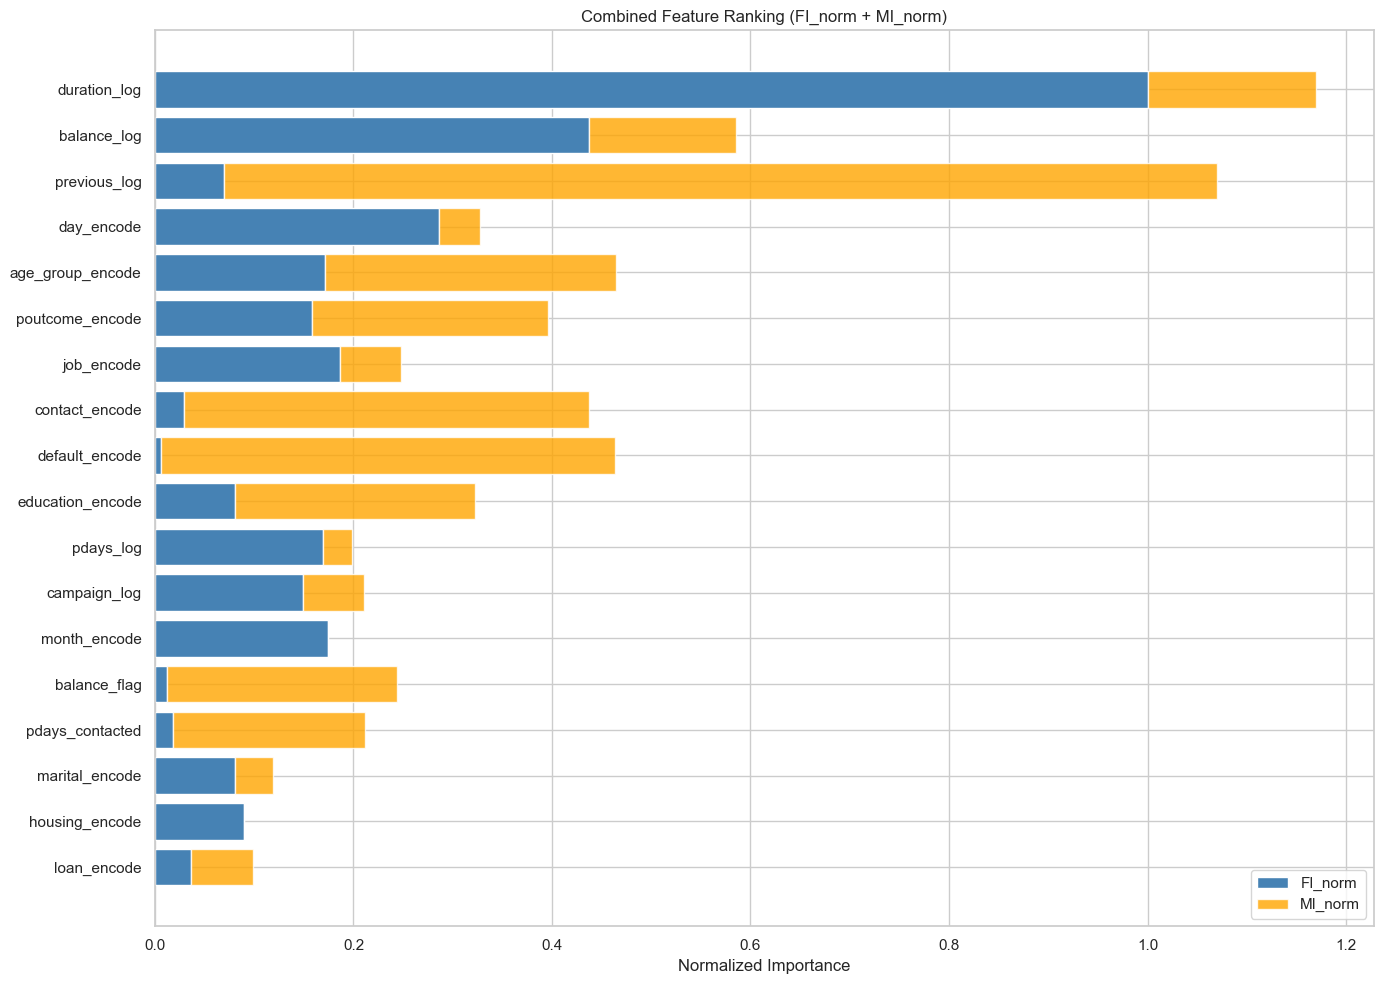

In [337]:
df_score_sorted = df_score_sorted.reset_index().rename(columns={"index": "feature"})
df_plot = df_score_sorted.copy()
df_plot = df_plot.sort_values("score", ascending=False)

plt.figure(figsize=(14, 10))

plt.barh(df_plot["feature"], df_plot["FI_norm"], color="steelblue", label="FI_norm")
plt.barh(df_plot["feature"], df_plot["MI_norm"], 
         left=df_plot["FI_norm"], color="orange", alpha=0.8, label="MI_norm")

plt.gca().invert_yaxis()

plt.title("Combined Feature Ranking (FI_norm + MI_norm)")
plt.xlabel("Normalized Importance")
plt.legend()
plt.tight_layout()
plt.show()


Việc kết hợp Feature Importances (FI) từ Random Forest và Mutual Information (MI) cho thấy rằng các đặc trưng quan trọng nhất bao gồm duration_log, balance_log, pdays_log, campaign_log, previous_log và các biến liên quan đến kết quả chiến dịch trước (poutcome). Đây là các biến được cả FI và MI đánh giá cao, chứng tỏ chúng mang nhiều thông tin và đóng góp mạnh cho mô hình dự đoán.

Ngược lại, các biến như loan, default, contact, marital và job ít phổ biến có giá trị FI và MI gần như bằng 0, nghĩa là hầu như không mang thông tin bổ sung. Vì vậy, chúng có thể được loại bỏ để giảm chiều dữ liệu và tránh nhiễu.

Do đó, việc xác định các nhóm đặc trưng Mạnh - Yếu để giữ lại và loại bỏ là rất quan trọng. Sau khi xem xét, chúng tôi quyết định chọn và loại bỏ các đặc trưng sau:

In [338]:
# Ngưỡng chọn feature
threshold = 0.05

selected_features = df_score_sorted.loc[df_score_sorted["score"] >= threshold, "feature"].tolist()

print("Selected Features Names:")
print(selected_features)

Selected Features Names:
['duration_log', 'balance_log', 'previous_log', 'day_encode', 'age_group_encode', 'poutcome_encode', 'job_encode', 'contact_encode', 'default_encode', 'education_encode', 'pdays_log', 'campaign_log', 'month_encode', 'balance_flag', 'pdays_contacted', 'marital_encode', 'housing_encode']


In [339]:
removed_features = df_score_sorted.loc[df_score_sorted["score"] < threshold, "feature"].tolist()

print("Removed Features")
print(removed_features)

Removed Features
['loan_encode']


### 10. Kiểm tra Multicollinearity (VIF)
VIF đo mức độ một feature có thể được dự đoán bởi các feature còn lại.

In [340]:
# xác nhận các numerical quan trọng không bị đa cộng tuyến (Multicolinearity)
numeric_cols = data.select_dtypes(include=["int64", "float64"]).columns.tolist()

# loại y nếu có trong numeric
numeric_cols = [c for c in numeric_cols if c != "y"]

X_num = data[numeric_cols]

# tính VIF
vif_df = pd.DataFrame()
vif_df["feature"] = X_num.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_num.values, i)
    for i in range(X_num.shape[1])
]

vif_df
vif_df

,feature,VIF
0,job_encode,2.896025
1,marital_encode,4.772468
2,education_encode,4.341348
3,default_encode,1.079755
4,balance_log,1.083479
5,balance_flag,1.239227
6,housing_encode,2.502961
7,loan_encode,1.232357
8,contact_encode,1.094405
9,day_encode,827.517662


Sau khi tính toán hệ số phồng phương sai (VIF), ta nhận thấy mức độ đa cộng tuyến giữa các đặc trưng có sự khác biệt rõ rệt giữa nhóm biến numerical thực sự và nhóm biến categorical đã được Label Encoding.

Các nhóm biến như (duration_log, balance_log, campaign_log, previous_log , balance_flag) đều có VIF < 5 cho thấy không tồn tại multicollinearity đáng kể và hoàn toàn có thể sử dụng cho mô hình hoá.

Hai biến liên quan đến lịch sử liên hệ: pdays_log (VIF ≈ 47.3) và pdays_contacted (VIF ≈ 65.6) có mức đa cộng tuyến cao vì chúng đều bắt nguồn từ cùng biến gốc pdays. Tuy nhiên: đây là đa cộng tuyến có chủ đích, phản ánh hai khía cạnh khác nhau (khoảng cách ngày và trạng thái đã được liên hệ) và các mô hình cây quyết định (Random Forest, XGBoost) không bị ảnh hưởng bởi multicollinearity => Vì vậy không cần loại bỏ hai biến này.

Nhóm các biến còn lại như: job, marital, education,... có VIF cao, nhưng không phải do đa cộng tuyến mà là do Label Encoding làm cho mô hình hiểu sai rằng các giá trị đó là thứ tự tuyến tính (nhưng thực chất là phân loại) nên VIF mới cao => không cần loại bỏ các biến này
Tập dữ liệu sau preprocessing ổn định, không có đa cộng tuyến gây hại.

In [341]:
df_final = data[selected_features]
df_final = pd.concat([df_final, df_job_onehot], axis=1)
df_final["y"] = data["y"]
df_final

,duration_log,balance_log,previous_log,day_encode,age_group_encode,poutcome_encode,job_encode,contact_encode,default_encode,education_encode,...,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,y
0,0.430097,0.507291,-0.424985,0.985243,4,3,4,0,0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,-0.160655,-0.588304,-0.424985,0.985243,3,3,9,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
2,-0.898547,-0.604089,-0.424985,0.985243,2,3,2,0,0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,-0.693703,0.203197,-0.424985,0.985243,3,3,1,0,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,-0.249885,-0.471857,-0.424985,0.985243,2,3,4,0,0,2.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45079,1.859241,-0.145264,-0.424985,0.998160,4,3,9,0,0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
45080,1.033733,0.311907,-0.424985,0.998160,0,3,5,0,0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
45081,2.014064,1.922291,2.173348,0.998160,0,2,5,0,0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1
45082,1.150659,-0.229402,-0.424985,0.998160,4,3,1,1,0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [342]:
OUTPUT_DIR = 'D:\\DS111\\DO AN\\Data Preparation\\processed_data' 
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Lưu
df_final.to_csv(os.path.join(OUTPUT_DIR, 'final_data.csv'), index=False)
print("Đã lưu thành công!")

Đã lưu thành công!
